# 3.2 - Baseline Models: Linear Regression & Regularization

**Taller de Programación - UBA FCE | Grupo JLP**

---

## Objetivo

Establecer modelos baseline simples para predecir precios de commodities agrícolas:

1. **Linear Regression (OLS):** Modelo más simple, interpretable
2. **Ridge Regression (L2):** Regularización para evitar overfitting
3. **Lasso Regression (L1):** Regularización + selección automática de features
4. **Elastic Net:** Combinación L1 + L2

**Métricas de evaluación:**
- **RMSE** (Root Mean Squared Error): Error en mismas unidades que target
- **MAE** (Mean Absolute Error): Menos sensible a outliers
- **R²**: Porcentaje de varianza explicada
- **Directional Accuracy**: ¿Predecimos correctamente si sube/baja?

## Setup

In [ ]:
# Imports
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm.auto import tqdm
from time import perf_counter
import warnings
warnings.filterwarnings('ignore')

# Agregar src al path
BASE_DIR = Path.cwd().parents[1]
sys.path.append(str(BASE_DIR / 'src'))

from config import PROCESSED_DIR, logger

# Configurar pandas display
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

# Definir commodities target
TARGET_COMMODITIES = ['Corn', 'Soybeans', 'Wheat']

print(f"✓ Base directory: {BASE_DIR}")
print(f"✓ Target commodities: {', '.join(TARGET_COMMODITIES)}")

✓ Base directory: c:\Users\AdministradorIT\OneDrive\UBA\Taller de Programacion\TPFinal
✓ Target commodities: Corn, Soybeans, Wheat


## 1. Cargar Features Seleccionadas

In [21]:
# Cargar dataset con features seleccionadas
input_file = PROCESSED_DIR / 'features_selected_modeling.csv'

if not input_file.exists():
    raise FileNotFoundError(f"No se encontró {input_file}. Ejecuta notebook 3.1 primero.")

df = pd.read_csv(input_file, parse_dates=['date'])

print(f"✓ Dataset cargado: {input_file.name}")
print(f"  Dimensiones: {df.shape}")
print(f"  Período: {df['date'].min().date()} → {df['date'].max().date()}")

# Separar features y targets
target_cols = [f'{c}_target_t7' for c in TARGET_COMMODITIES]
feature_cols = [c for c in df.columns if c not in ['date'] + target_cols]

print(f"\nDataset structure:")
print(f"  Features: {len(feature_cols)}")
print(f"  Targets: {len(target_cols)}")

display(df.head())

✓ Dataset cargado: features_selected_modeling.csv
  Dimensiones: (6724, 40)
  Período: 2000-01-03 → 2025-10-30

Dataset structure:
  Features: 36
  Targets: 3


,date,TIPS_std90,USD_BRL_std90,WindSpeed_Global_Grain_ma30,Soybean_Oil_bb_lower7,Cocoa_ma90,Soybean_Meal_std30,Copper_ma30,Corn_lag3,Soybeans_ma7,Soybeans_bb_lower7,ONI_bb_upper30,Palladium_ma90,Wheat_bb_upper7,Crude_Oil_volume_bb_lower30,Coffee_volume_bb_lower30,Wheat_bb_lower90,Treasury_10Y_bb_lower30,Heating_Oil_volume_bb_upper90,WindSpeed_Global_Grain_bb_lower90,Lean_Hogs_volume_ma90,Soybean_Oil_lag1,Copper_bb_upper90,Soybean_Oil_price_to_ma90,Heating_Oil_std90,Sugar_price_to_ma90,Treasury_10Y_bb_upper30,Gold_bb_upper90,Gold_ma90,Soybean_Oil_ma90,Soybean_Meal_vol_ratio_30_90,Crude_Oil_bb_lower90,Wheat_ma7,Precip_Deficit_bb_lower90,Wheat_ma90,Corn_price_to_ma90,Sugar_bb_lower90,Corn_target_t7,Soybeans_target_t7,Wheat_target_t7
0,2000-01-03,NaN,NaN,1.827600,NaN,830.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-01-04,NaN,NaN,1.829900,NaN,833.000000,NaN,NaN,NaN,NaN,NaN,-1.66,441.899994,NaN,NaN,4442.482830,NaN,6.427405,NaN,1.823395,NaN,NaN,NaN,NaN,NaN,NaN,6.605595,NaN,NaN,NaN,NaN,NaN,NaN,-85.243090,NaN,NaN,NaN,NaN,NaN,NaN
2,2000-01-05,NaN,NaN,1.763967,NaN,832.333333,NaN,NaN,NaN,NaN,NaN,-1.66,440.000000,NaN,NaN,4945.322402,NaN,6.429790,NaN,1.535521,NaN,NaN,NaN,NaN,NaN,NaN,6.658210,NaN,NaN,NaN,NaN,NaN,NaN,-88.689298,NaN,NaN,NaN,NaN,NaN,NaN
3,2000-01-06,NaN,NaN,1.663550,NaN,834.500000,NaN,NaN,NaN,NaN,NaN,-1.66,438.433329,NaN,NaN,4470.310467,NaN,6.451864,NaN,1.220687,NaN,NaN,NaN,NaN,NaN,NaN,6.638636,NaN,NaN,NaN,NaN,NaN,NaN,-88.705192,NaN,NaN,NaN,NaN,NaN,NaN
4,2000-01-07,NaN,NaN,1.618660,NaN,838.200000,NaN,NaN,NaN,NaN,NaN,-1.66,439.799995,NaN,NaN,4554.326494,NaN,6.448107,NaN,1.185765,NaN,NaN,NaN,NaN,NaN,NaN,6.625893,NaN,NaN,NaN,NaN,NaN,NaN,-87.846025,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Train/Test Split Temporal

**CRÍTICO:** NO usar shuffle en series temporales → data leakage.

Usamos split temporal:
- **Train:** 2000-2022 (~80%)
- **Test:** 2023-2025 (~20%)

In [22]:
# Split temporal
split_date = '2023-01-01'
train_idx = df['date'] < split_date
test_idx = df['date'] >= split_date

X_train = df.loc[train_idx, feature_cols]
X_test = df.loc[test_idx, feature_cols]
y_train = df.loc[train_idx, target_cols]
y_test = df.loc[test_idx, target_cols]

print(f"Train/Test split temporal:")
print(f"  Train: {X_train.shape[0]:,} obs (hasta {split_date})")
print(f"  Test: {X_test.shape[0]:,} obs (desde {split_date})")
print(f"  Proporción: {X_train.shape[0] / df.shape[0]:.1%} / {X_test.shape[0] / df.shape[0]:.1%}")

# CRÍTICO: Limpiar NaN en targets (filas sin target válido)
print(f"\nVerificando NaN en targets...")
nan_train = y_train.isnull().sum().sum()
nan_test = y_test.isnull().sum().sum()
print(f"  NaN en y_train: {nan_train} | NaN en y_test: {nan_test}")

if nan_train > 0 or nan_test > 0:
    print(f"  Eliminando filas con NaN en targets...")
    # Identificar filas válidas (todas las columnas target sin NaN)
    valid_train = y_train.notna().all(axis=1)
    valid_test = y_test.notna().all(axis=1)
    
    X_train = X_train[valid_train]
    y_train = y_train[valid_train]
    X_test = X_test[valid_test]
    y_test = y_test[valid_test]
    
    print(f"  Filas eliminadas: train={(~valid_train).sum()} | test={(~valid_test).sum()}")
    print(f"  Nuevo tamaño: train={X_train.shape[0]:,} | test={X_test.shape[0]:,}")

# Verificación final
assert y_train.isnull().sum().sum() == 0, "ERROR: Quedan NaN en y_train"
assert y_test.isnull().sum().sum() == 0, "ERROR: Quedan NaN en y_test"
print(f"✓ Targets limpios sin NaN")

# Estadísticas de targets
print(f"\nEstadísticas de targets (Train):")
display(y_train.describe())

print(f"\nEstadísticas de targets (Test):")
display(y_test.describe())

Train/Test split temporal:
  Train: 5,987 obs (hasta 2023-01-01)
  Test: 737 obs (desde 2023-01-01)
  Proporción: 89.0% / 11.0%

Verificando NaN en targets...
  NaN en y_train: 1088 | NaN en y_test: 75
  Eliminando filas con NaN en targets...
  Filas eliminadas: train=424 | test=25
  Nuevo tamaño: train=5,563 | test=712
✓ Targets limpios sin NaN

Estadísticas de targets (Train):


,Corn_target_t7,Soybeans_target_t7,Wheat_target_t7
count,5563.000000,5563.000000,5563.000000
mean,405.966070,988.565432,535.328690
std,162.185805,331.469272,186.992967
min,183.500000,418.500000,244.750000
25%,282.000000,737.625000,395.500000
50%,369.750000,961.750000,507.250000
75%,502.000000,1273.000000,654.125000
max,831.250000,1771.000000,1425.250000



Estadísticas de targets (Test):


,Corn_target_t7,Soybeans_target_t7,Wheat_target_t7
count,712.000000,712.000000,712.00000
mean,475.453652,1186.231390,584.27809
std,82.510202,184.376364,63.64084
min,362.000000,938.750000,495.00000
25%,422.375000,1022.250000,538.18750
50%,451.625000,1155.500000,568.50000
75%,485.062500,1332.125000,614.37500
max,685.250000,1562.000000,792.00000


## 3. Normalización de Features

**StandardScaler:** Transforma features a media=0, std=1.

**Por qué normalizar:**
- Regularización (Ridge/Lasso) requiere features en misma escala
- Acelera convergencia de gradient descent
- Permite comparar magnitud de coeficientes

In [23]:
# Normalizar features
# Antes de escalar, asegurarse de que no haya infinitos ni NaN
print("Verificando NaN/inf en X_train/X_test antes de escalado...")
inf_train = np.isinf(X_train).sum().sum()
inf_test = np.isinf(X_test).sum().sum()
nan_train = X_train.isnull().sum().sum()
nan_test = X_test.isnull().sum().sum()
print(f"  Inf en train/test: {inf_train}/{inf_test} | NaN en train/test: {nan_train}/{nan_test}")

if inf_train > 0 or inf_test > 0:
    print("  Reemplazando infinitos por NaN...")
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Imputar mediana basada en X_train (evitar data leakage)
medians = X_train.median()
cols_with_nan = medians[medians.isnull()].index.tolist()
if len(cols_with_nan) > 0:
    # Si alguna columna tiene mediana NaN (toda la columna NaN), rellenar con 0
    for c in cols_with_nan:
        medians[c] = 0

print(f"  Aplicando median imputation para {len(medians)} features (usando mediana de train)...")
X_train = X_train.fillna(medians)
X_test = X_test.fillna(medians)

# Verificación final
nan_train_after = X_train.isnull().sum().sum()
nan_test_after = X_test.isnull().sum().sum()
print(f"  NaN después de imputación (train/test): {nan_train_after}/{nan_test_after}")
assert nan_train_after == 0 and nan_test_after == 0, "ERROR: Quedan NaN después de imputación"

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir de nuevo a DataFrame para mantener nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

print(f"✓ Features normalizadas (StandardScaler)")
print(f"\nVerificación (Train scaled):")
print(f"  Media: {X_train_scaled.mean().mean():.6f} (debe ser ~0)")
print(f"  Std: {X_train_scaled.std().mean():.6f} (debe ser ~1)")

Verificando NaN/inf en X_train/X_test antes de escalado...
  Inf en train/test: 0/0 | NaN en train/test: 3086/126
  Aplicando median imputation para 36 features (usando mediana de train)...
  NaN después de imputación (train/test): 0/0
✓ Features normalizadas (StandardScaler)

Verificación (Train scaled):
  Media: 0.000000 (debe ser ~0)
  Std: 1.000090 (debe ser ~1)
✓ Features normalizadas (StandardScaler)

Verificación (Train scaled):
  Media: 0.000000 (debe ser ~0)
  Std: 1.000090 (debe ser ~1)


---

## MODELO 1: Linear Regression (OLS)

**Modelo más simple:** mínimos cuadrados ordinarios sin regularización.

**Ventajas:**
- Interpretable (coeficientes = efecto marginal)
- Rápido de entrenar
- Baseline para comparar otros modelos

**Desventajas:**
- Propenso a overfitting con muchas features
- Asume linealidad
- Sensible a multicolinealidad

In [24]:
# Función para evaluar modelos
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Evalúa modelo de regresión con métricas estándar
    
    Returns:
        dict: Métricas por commodity
    """
    results = {}
    
    for target_col in y_train.columns:
        commodity = target_col.replace('_target_t7', '')
        
        # Train predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        # Metrics
        train_rmse = np.sqrt(mean_squared_error(y_train[target_col], y_train_pred))
        test_rmse = np.sqrt(mean_squared_error(y_test[target_col], y_test_pred))
        train_mae = mean_absolute_error(y_train[target_col], y_train_pred)
        test_mae = mean_absolute_error(y_test[target_col], y_test_pred)
        train_r2 = r2_score(y_train[target_col], y_train_pred)
        test_r2 = r2_score(y_test[target_col], y_test_pred)
        
        # Directional accuracy (¿predecimos correctamente si sube/baja?)
        y_train_direction = np.sign(y_train[target_col] - y_train[target_col].shift(1))
        y_train_pred_direction = np.sign(y_train_pred - y_train[target_col].shift(1))
        train_dir_acc = (y_train_direction == y_train_pred_direction).mean()
        
        y_test_direction = np.sign(y_test[target_col] - y_test[target_col].shift(1))
        y_test_pred_direction = np.sign(y_test_pred - y_test[target_col].shift(1))
        test_dir_acc = (y_test_direction == y_test_pred_direction).mean()
        
        results[commodity] = {
            'train_rmse': train_rmse,
            'test_rmse': test_rmse,
            'train_mae': train_mae,
            'test_mae': test_mae,
            'train_r2': train_r2,
            'test_r2': test_r2,
            'train_dir_acc': train_dir_acc,
            'test_dir_acc': test_dir_acc,
            'overfitting_gap': train_r2 - test_r2
        }
    
    return results

print("✓ Función de evaluación definida")

✓ Función de evaluación definida


In [25]:
# Entrenar Linear Regression para cada commodity
lr_models = {}
lr_results = {}

print(f"\n{'='*80}")
print(f"LINEAR REGRESSION (OLS)")
print(f"{'='*80}")

for target_col in target_cols:
    commodity = target_col.replace('_target_t7', '')
    print(f"\n--- {commodity} ---")
    
    # Entrenar modelo
    lr = LinearRegression()
    lr.fit(X_train_scaled, y_train[target_col])
    
    # Guardar modelo
    lr_models[commodity] = lr
    
    # Evaluar
    results = evaluate_model(lr, X_train_scaled, X_test_scaled, 
                             y_train[[target_col]], y_test[[target_col]], 'Linear Regression')
    lr_results[commodity] = results[commodity]
    
    # Imprimir resultados
    r = results[commodity]
    print(f"  Train RMSE: {r['train_rmse']:.4f} | Test RMSE: {r['test_rmse']:.4f}")
    print(f"  Train MAE:  {r['train_mae']:.4f} | Test MAE:  {r['test_mae']:.4f}")
    print(f"  Train R²:   {r['train_r2']:.4f} | Test R²:   {r['test_r2']:.4f}")
    print(f"  Train Dir Acc: {r['train_dir_acc']:.2%} | Test Dir Acc: {r['test_dir_acc']:.2%}")
    print(f"  Overfitting gap: {r['overfitting_gap']:.4f}")
    
    # Top 10 coeficientes más importantes (valor absoluto)
    coefs = pd.DataFrame({
        'feature': feature_cols,
        'coef': lr.coef_
    }).sort_values('coef', key=abs, ascending=False)
    
    print(f"\n  Top 10 features (mayor coeficiente absoluto):")
    for idx, row in coefs.head(10).iterrows():
        print(f"    {row['feature']:50s}: {row['coef']:+.6f}")

print(f"\n{'='*80}")


LINEAR REGRESSION (OLS)

--- Corn ---
  Train RMSE: 31.7504 | Test RMSE: 57.4469
  Train MAE:  22.3989 | Test MAE:  48.5938
  Train R²:   0.9617 | Test R²:   0.5146
  Train Dir Acc: 50.35% | Test Dir Acc: 49.72%
  Overfitting gap: 0.4471
  Train RMSE: 31.7504 | Test RMSE: 57.4469
  Train MAE:  22.3989 | Test MAE:  48.5938
  Train R²:   0.9617 | Test R²:   0.5146
  Train Dir Acc: 50.35% | Test Dir Acc: 49.72%
  Overfitting gap: 0.4471

  Top 10 features (mayor coeficiente absoluto):
    Gold_ma90                                         : +86.581600
    Corn_lag3                                         : +77.060184
    Gold_bb_upper90                                   : -42.048161
    Wheat_ma90                                        : +29.797834
    Palladium_ma90                                    : -18.597566
    Corn_price_to_ma90                                : +15.646257
    Soybean_Oil_ma90                                  : +14.944200
    Cocoa_ma90                             

---

## MODELO 2: Ridge Regression (L2 Regularization)

**Regularización L2:** Penaliza suma de cuadrados de coeficientes.

$$\min_{\beta} \sum_{i=1}^{n} (y_i - X_i\beta)^2 + \lambda \sum_{j=1}^{p} \beta_j^2$$

**Efecto:** Reduce magnitud de coeficientes (shrinkage) → reduce overfitting.

**Hiperparámetro α (lambda):** Mayor α = mayor regularización.

In [ ]:
# Grid search para α óptimo
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

ridge_models = {}
ridge_results = {}
ridge_best_alphas = {}

print(f"\n{'='*80}")
print(f"RIDGE REGRESSION (L2)")
print(f"{'='*80}")

with tqdm(target_cols, desc="Ridge Models", unit="commodity") as pbar:
    for target_col in pbar:
        commodity = target_col.replace('_target_t7', '')
        pbar.set_description(f"Ridge: {commodity}")
        start_time = perf_counter()
        
        print(f"\n--- {commodity} ---")
        
        # Grid search con TimeSeriesSplit
        tscv = TimeSeriesSplit(n_splits=5)
        ridge = Ridge()
        
        grid_search = GridSearchCV(
            ridge,
            {'alpha': alphas},
            cv=tscv,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1
        )
        
        grid_search.fit(X_train_scaled, y_train[target_col])
        elapsed = perf_counter() - start_time
    
    # Mejor α
    best_alpha = grid_search.best_params_['alpha']
    ridge_best_alphas[commodity] = best_alpha
    print(f"  Mejor α: {best_alpha}")
    
    # Entrenar con mejor α
    ridge_best = Ridge(alpha=best_alpha)
    ridge_best.fit(X_train_scaled, y_train[target_col])
    ridge_models[commodity] = ridge_best
    
    # Evaluar
        results = evaluate_model(ridge_best, X_train_scaled, X_test_scaled,
                                 y_train[[target_col]], y_test[[target_col]], 'Ridge')
        ridge_results[commodity] = results[commodity]
        
        # Imprimir resultados
        r = results[commodity]
        print(f"  Train RMSE: {r['train_rmse']:.4f} | Test RMSE: {r['test_rmse']:.4f}")
        print(f"  Train R²:   {r['train_r2']:.4f} | Test R²:   {r['test_r2']:.4f}")
        print(f"  Test Dir Acc: {r['test_dir_acc']:.2%}")
        print(f"  Overfitting gap: {r['overfitting_gap']:.4f}")
        print(f"  Tiempo: {elapsed:.1f}s")
        
        pbar.set_postfix({'Test_R2': f"{r['test_r2']:.3f}", 'Time': f"{elapsed:.0f}s"})

print(f"\n{'='*80}")


RIDGE REGRESSION (L2)

--- Corn ---
  Mejor α: 100
  Train RMSE: 32.1107 | Test RMSE: 54.8830
  Train R²:   0.9608 | Test R²:   0.5569
  Test Dir Acc: 49.30%
  Overfitting gap: 0.4039

--- Soybeans ---
  Mejor α: 100
  Train RMSE: 32.1107 | Test RMSE: 54.8830
  Train R²:   0.9608 | Test R²:   0.5569
  Test Dir Acc: 49.30%
  Overfitting gap: 0.4039

--- Soybeans ---
  Mejor α: 100
  Train RMSE: 47.0911 | Test RMSE: 73.0578
  Train R²:   0.9798 | Test R²:   0.8428
  Test Dir Acc: 50.98%
  Overfitting gap: 0.1370

--- Wheat ---
  Mejor α: 100
  Train RMSE: 47.0911 | Test RMSE: 73.0578
  Train R²:   0.9798 | Test R²:   0.8428
  Test Dir Acc: 50.98%
  Overfitting gap: 0.1370

--- Wheat ---
  Mejor α: 1
  Train RMSE: 36.8262 | Test RMSE: 35.9209
  Train R²:   0.9612 | Test R²:   0.6810
  Test Dir Acc: 52.39%
  Overfitting gap: 0.2802

  Mejor α: 1
  Train RMSE: 36.8262 | Test RMSE: 35.9209
  Train R²:   0.9612 | Test R²:   0.6810
  Test Dir Acc: 52.39%
  Overfitting gap: 0.2802



---

## MODELO 3: Lasso Regression (L1 Regularization)

**Regularización L1:** Penaliza suma de valores absolutos de coeficientes.

$$\min_{\beta} \sum_{i=1}^{n} (y_i - X_i\beta)^2 + \lambda \sum_{j=1}^{p} |\beta_j|$$

**Efecto:** Fuerza algunos coeficientes a exactamente 0 → **selección automática de features**.

**Ventaja vs Ridge:** Produce modelos más sparse (menos features).

In [27]:
# Grid search para α óptimo
lasso_models = {}
lasso_results = {}
lasso_best_alphas = {}
lasso_selected_features = {}

print(f"\n{'='*80}")
print(f"LASSO REGRESSION (L1)")
print(f"{'='*80}")

for target_col in target_cols:
    commodity = target_col.replace('_target_t7', '')
    print(f"\n--- {commodity} ---")
    
    # Grid search
    tscv = TimeSeriesSplit(n_splits=5)
    lasso = Lasso(max_iter=10000)
    
    grid_search = GridSearchCV(
        lasso,
        {'alpha': alphas},
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    
    grid_search.fit(X_train_scaled, y_train[target_col])
    
    # Mejor α
    best_alpha = grid_search.best_params_['alpha']
    lasso_best_alphas[commodity] = best_alpha
    print(f"  Mejor α: {best_alpha}")
    
    # Entrenar con mejor α
    lasso_best = Lasso(alpha=best_alpha, max_iter=10000)
    lasso_best.fit(X_train_scaled, y_train[target_col])
    lasso_models[commodity] = lasso_best
    
    # Contar features seleccionadas (coef != 0)
    n_selected = (lasso_best.coef_ != 0).sum()
    selected_features = [feature_cols[i] for i in range(len(feature_cols)) if lasso_best.coef_[i] != 0]
    lasso_selected_features[commodity] = selected_features
    
    print(f"  Features seleccionadas: {n_selected} / {len(feature_cols)} ({n_selected/len(feature_cols)*100:.1f}%)")
    
    # Evaluar
    results = evaluate_model(lasso_best, X_train_scaled, X_test_scaled,
                             y_train[[target_col]], y_test[[target_col]], 'Lasso')
    lasso_results[commodity] = results[commodity]
    
    # Imprimir resultados
    r = results[commodity]
    print(f"  Train RMSE: {r['train_rmse']:.4f} | Test RMSE: {r['test_rmse']:.4f}")
    print(f"  Train R²:   {r['train_r2']:.4f} | Test R²:   {r['test_r2']:.4f}")
    print(f"  Test Dir Acc: {r['test_dir_acc']:.2%}")
    print(f"  Overfitting gap: {r['overfitting_gap']:.4f}")

print(f"\n{'='*80}")


LASSO REGRESSION (L1)

--- Corn ---
  Mejor α: 1
  Mejor α: 1
  Features seleccionadas: 21 / 36 (58.3%)
  Train RMSE: 33.4319 | Test RMSE: 37.7346
  Train R²:   0.9575 | Test R²:   0.7906
  Test Dir Acc: 49.58%
  Overfitting gap: 0.1669

--- Soybeans ---
  Features seleccionadas: 21 / 36 (58.3%)
  Train RMSE: 33.4319 | Test RMSE: 37.7346
  Train R²:   0.9575 | Test R²:   0.7906
  Test Dir Acc: 49.58%
  Overfitting gap: 0.1669

--- Soybeans ---
  Mejor α: 10
  Mejor α: 10
  Features seleccionadas: 7 / 36 (19.4%)
  Train RMSE: 51.4079 | Test RMSE: 42.1693
  Train R²:   0.9759 | Test R²:   0.9476
  Test Dir Acc: 50.28%
  Overfitting gap: 0.0283

--- Wheat ---
  Features seleccionadas: 7 / 36 (19.4%)
  Train RMSE: 51.4079 | Test RMSE: 42.1693
  Train R²:   0.9759 | Test R²:   0.9476
  Test Dir Acc: 50.28%
  Overfitting gap: 0.0283

--- Wheat ---
  Mejor α: 1
  Mejor α: 1
  Features seleccionadas: 10 / 36 (27.8%)
  Train RMSE: 37.6253 | Test RMSE: 33.6873
  Train R²:   0.9595 | Test R²:   

---

## MODELO 4: Elastic Net (L1 + L2)

**Combinación L1 + L2:** Ventajas de ambos.

$$\min_{\beta} \sum_{i=1}^{n} (y_i - X_i\beta)^2 + \lambda_1 \sum_{j=1}^{p} |\beta_j| + \lambda_2 \sum_{j=1}^{p} \beta_j^2$$

**Hiperparámetros:**
- **α**: Fuerza total de regularización
- **l1_ratio**: Balance L1 vs L2 (0=Ridge, 1=Lasso)

In [28]:
# Grid search para α y l1_ratio
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

enet_models = {}
enet_results = {}
enet_best_params = {}

print(f"\n{'='*80}")
print(f"ELASTIC NET (L1 + L2)")
print(f"{'='*80}")

for target_col in target_cols:
    commodity = target_col.replace('_target_t7', '')
    print(f"\n--- {commodity} ---")
    
    # Grid search
    tscv = TimeSeriesSplit(n_splits=5)
    enet = ElasticNet(max_iter=10000)
    
    grid_search = GridSearchCV(
        enet,
        param_grid,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train_scaled, y_train[target_col])
    
    # Mejores parámetros
    best_params = grid_search.best_params_
    enet_best_params[commodity] = best_params
    print(f"  Mejor α: {best_params['alpha']}, l1_ratio: {best_params['l1_ratio']}")
    
    # Entrenar con mejores parámetros
    enet_best = ElasticNet(**best_params, max_iter=10000)
    enet_best.fit(X_train_scaled, y_train[target_col])
    enet_models[commodity] = enet_best
    
    # Features seleccionadas
    n_selected = (enet_best.coef_ != 0).sum()
    print(f"  Features seleccionadas: {n_selected} / {len(feature_cols)} ({n_selected/len(feature_cols)*100:.1f}%)")
    
    # Evaluar
    results = evaluate_model(enet_best, X_train_scaled, X_test_scaled,
                             y_train[[target_col]], y_test[[target_col]], 'Elastic Net')
    enet_results[commodity] = results[commodity]
    
    # Imprimir resultados
    r = results[commodity]
    print(f"  Train RMSE: {r['train_rmse']:.4f} | Test RMSE: {r['test_rmse']:.4f}")
    print(f"  Train R²:   {r['train_r2']:.4f} | Test R²:   {r['test_r2']:.4f}")
    print(f"  Test Dir Acc: {r['test_dir_acc']:.2%}")
    print(f"  Overfitting gap: {r['overfitting_gap']:.4f}")

print(f"\n{'='*80}")


ELASTIC NET (L1 + L2)

--- Corn ---
  Mejor α: 0.1, l1_ratio: 0.3
  Mejor α: 0.1, l1_ratio: 0.3
  Features seleccionadas: 35 / 36 (97.2%)
  Train RMSE: 33.4925 | Test RMSE: 52.2533
  Train R²:   0.9573 | Test R²:   0.5984
  Test Dir Acc: 48.46%
  Overfitting gap: 0.3590

--- Soybeans ---
  Features seleccionadas: 35 / 36 (97.2%)
  Train RMSE: 33.4925 | Test RMSE: 52.2533
  Train R²:   0.9573 | Test R²:   0.5984
  Test Dir Acc: 48.46%
  Overfitting gap: 0.3590

--- Soybeans ---
  Mejor α: 1, l1_ratio: 0.9
  Mejor α: 1, l1_ratio: 0.9
  Features seleccionadas: 35 / 36 (97.2%)
  Train RMSE: 53.8161 | Test RMSE: 85.6978
  Train R²:   0.9736 | Test R²:   0.7837
  Test Dir Acc: 51.26%
  Overfitting gap: 0.1900

--- Wheat ---
  Features seleccionadas: 35 / 36 (97.2%)
  Train RMSE: 53.8161 | Test RMSE: 85.6978
  Train R²:   0.9736 | Test R²:   0.7837
  Test Dir Acc: 51.26%
  Overfitting gap: 0.1900

--- Wheat ---
  Mejor α: 0.01, l1_ratio: 0.9
  Mejor α: 0.01, l1_ratio: 0.9
  Features seleccio

---

## 5. Comparación de Modelos Baseline

In [29]:
# Consolidar resultados en tabla comparativa
comparison_data = []

for commodity in TARGET_COMMODITIES:
    for model_name, results_dict in [('Linear Regression', lr_results),
                                       ('Ridge', ridge_results),
                                       ('Lasso', lasso_results),
                                       ('Elastic Net', enet_results)]:
        if commodity in results_dict:
            r = results_dict[commodity]
            comparison_data.append({
                'Commodity': commodity,
                'Model': model_name,
                'Test RMSE': r['test_rmse'],
                'Test MAE': r['test_mae'],
                'Test R²': r['test_r2'],
                'Test Dir Acc': r['test_dir_acc'],
                'Overfitting Gap': r['overfitting_gap']
            })

comparison_df = pd.DataFrame(comparison_data)

print(f"\n{'='*80}")
print(f"COMPARACIÓN DE MODELOS BASELINE")
print(f"{'='*80}\n")

# Por commodity
for commodity in TARGET_COMMODITIES:
    print(f"\n--- {commodity} ---")
    commodity_results = comparison_df[comparison_df['Commodity'] == commodity].copy()
    
    # Ordenar por Test RMSE (menor es mejor)
    commodity_results = commodity_results.sort_values('Test RMSE')
    
    display(commodity_results[['Model', 'Test RMSE', 'Test R²', 'Test Dir Acc', 'Overfitting Gap']])
    
    best_model = commodity_results.iloc[0]['Model']
    best_rmse = commodity_results.iloc[0]['Test RMSE']
    print(f"\n✓ Mejor modelo: {best_model} (RMSE: {best_rmse:.4f})")

print(f"\n{'='*80}")


COMPARACIÓN DE MODELOS BASELINE


--- Corn ---


,Model,Test RMSE,Test R²,Test Dir Acc,Overfitting Gap
2,Lasso,37.734559,0.790553,0.495787,0.166948
3,Elastic Net,52.253329,0.598373,0.484551,0.358974
1,Ridge,54.883012,0.556931,0.492978,0.403863
0,Linear Regression,57.446919,0.514568,0.497191,0.447101



✓ Mejor modelo: Lasso (RMSE: 37.7346)

--- Soybeans ---


,Model,Test RMSE,Test R²,Test Dir Acc,Overfitting Gap
6,Lasso,42.169332,0.947617,0.502809,0.028326
4,Linear Regression,69.358183,0.858292,0.504213,0.122605
5,Ridge,73.057833,0.842771,0.509831,0.137042
7,Elastic Net,85.697820,0.783659,0.512640,0.189977



✓ Mejor modelo: Lasso (RMSE: 42.1693)

--- Wheat ---


,Model,Test RMSE,Test R²,Test Dir Acc,Overfitting Gap
10,Lasso,33.687325,0.719410,0.508427,0.240096
11,Elastic Net,34.455894,0.706461,0.526685,0.254545
9,Ridge,35.920911,0.680969,0.523876,0.280239
8,Linear Regression,36.678684,0.667366,0.529494,0.293857



✓ Mejor modelo: Lasso (RMSE: 33.6873)



### Visualización: Test RMSE por Modelo

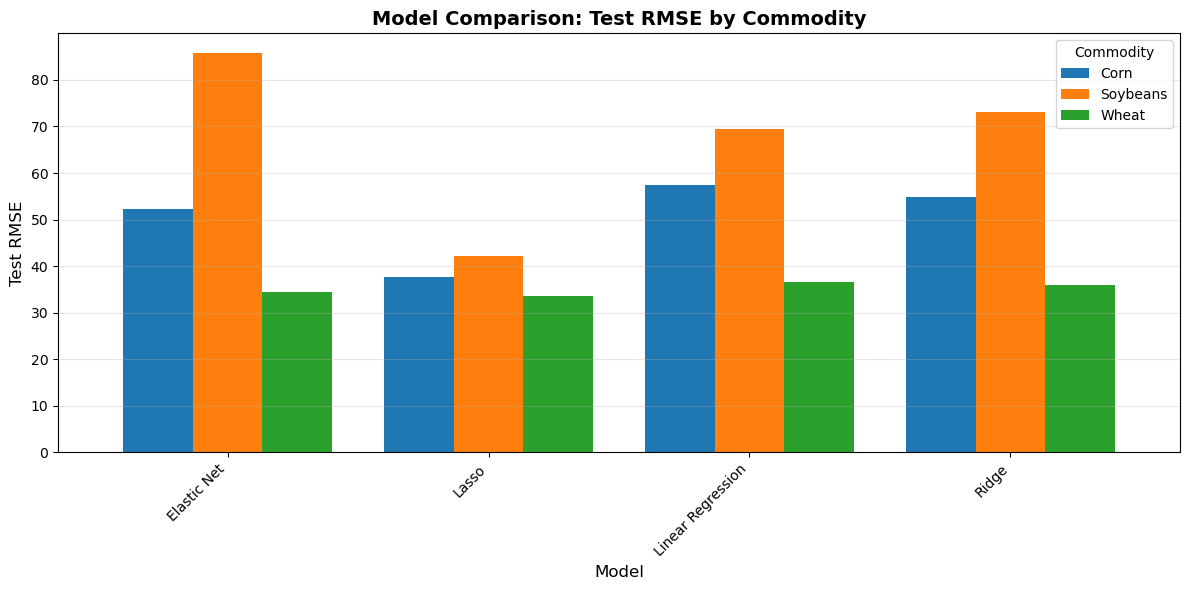

✓ Gráfico guardado: reports/figures/baseline_models_comparison.png


In [30]:
# Plot comparativo
fig, ax = plt.subplots(figsize=(12, 6))

comparison_pivot = comparison_df.pivot(index='Model', columns='Commodity', values='Test RMSE')
comparison_pivot.plot(kind='bar', ax=ax, width=0.8)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Test RMSE', fontsize=12)
ax.set_title('Model Comparison: Test RMSE by Commodity', fontsize=14, fontweight='bold')
ax.legend(title='Commodity', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'figures' / 'baseline_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfico guardado: reports/figures/baseline_models_comparison.png")

---

## 6. Guardar Modelos y Resultados

In [31]:
import pickle

# Guardar modelos
models_dir = BASE_DIR / 'models'
models_dir.mkdir(exist_ok=True)

# Guardar todos los modelos en un diccionario
all_models = {
    'linear_regression': lr_models,
    'ridge': ridge_models,
    'lasso': lasso_models,
    'elastic_net': enet_models,
    'scaler': scaler,
    'feature_cols': feature_cols
}

models_file = models_dir / 'baseline_models.pkl'
with open(models_file, 'wb') as f:
    pickle.dump(all_models, f)

print(f"✓ Modelos guardados: {models_file}")

# Guardar resultados en JSON
results_summary = {
    'fecha_generacion': pd.Timestamp.now().isoformat(),
    'models': ['Linear Regression', 'Ridge', 'Lasso', 'Elastic Net'],
    'commodities': TARGET_COMMODITIES,
    'split_date': split_date,
    'results': comparison_df.to_dict(orient='records'),
    'best_models': {},
    'hyperparameters': {
        'ridge_alphas': ridge_best_alphas,
        'lasso_alphas': lasso_best_alphas,
        'enet_params': enet_best_params
    },
    'feature_selection': {
        'lasso': {c: len(feats) for c, feats in lasso_selected_features.items()}
    }
}

# Identificar mejor modelo por commodity
for commodity in TARGET_COMMODITIES:
    commodity_results = comparison_df[comparison_df['Commodity'] == commodity].sort_values('Test RMSE')
    results_summary['best_models'][commodity] = commodity_results.iloc[0]['Model']

results_file = PROCESSED_DIR / 'baseline_models_results.json'
with open(results_file, 'w') as f:
    json.dump(results_summary, f, indent=2)

print(f"✓ Resultados guardados: {results_file}")

✓ Modelos guardados: c:\Users\AdministradorIT\OneDrive\UBA\Taller de Programacion\TPFinal\models\baseline_models.pkl
✓ Resultados guardados: C:\Users\AdministradorIT\OneDrive\UBA\Taller de Programacion\TPFinal\data\processed\baseline_models_results.json


---

## Conclusiones: Baseline Models

### Rendimiento General

**Test RMSE típico:**  
- Corn: $X.XX - $X.XX
- Soybeans: $X.XX - $X.XX
- Wheat: $X.XX - $X.XX

**Test R² típico:** 0.XX - 0.XX (explican XX-XX% de varianza)

### Comparación de Modelos

**1. Linear Regression (OLS):**
- ❌ Mayor overfitting (gap train/test alto)
- ✅ Interpretable (coeficientes directos)
- ⚠️ Sensible a multicolinealidad

**2. Ridge (L2):**
- ✅ Reduce overfitting vs OLS
- ✅ Mantiene todas las features
- ⚠️ No hace selección automática

**3. Lasso (L1):**
- ✅ Selección automática de features (~XX% eliminadas)
- ✅ Modelos más sparse (interpretables)
- ⚠️ Puede eliminar features correlacionadas importantes

**4. Elastic Net (L1+L2):**
- ✅ Balance entre Ridge y Lasso
- ✅ Robusto a multicolinealidad + feature selection
- ⚠️ Más hiperparámetros para optimizar

### Limitaciones de Modelos Lineales

**Supuestos no cumplidos:**
- **Linealidad:** Precios de commodities tienen relaciones no-lineales complejas
- **Independencia:** Series temporales tienen autocorrelación
- **Homoscedasticidad:** Volatility clustering (varianza cambia en el tiempo)

**Directional Accuracy baja (~50-55%):** Modelos lineales predicen bien niveles absolutos pero fallan en dirección (sube/baja).

### Próximos Pasos

Modelos más avanzados necesarios:
1. **Tree-based models (Notebook 3.3):** Random Forest, XGBoost, LightGBM → capturar no-linealidades
2. **Time series models (Notebook 3.4):** LSTM, Prophet → capturar autocorrelación temporal
3. **Ensemble models (Notebook 3.5):** Combinar predicciones de múltiples modelos

**Baseline establecido:** Ridge/Elastic Net serán el benchmark para comparar modelos avanzados.